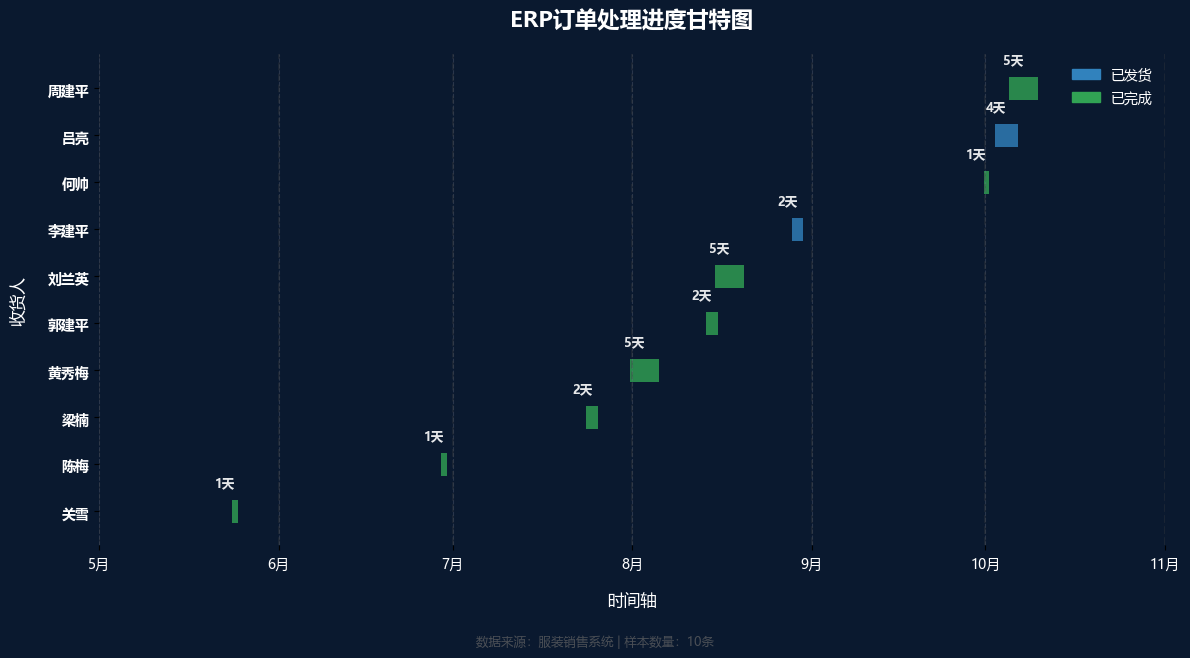

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import timedelta

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 严格读取CSV文件
    orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['下单时间', '付款日期', '发货日期', '状态', '收货人']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 转换日期列
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    orders['付款日期'] = pd.to_datetime(orders['付款日期'], errors='coerce')
    orders['发货日期'] = pd.to_datetime(orders['发货日期'], errors='coerce')
    
    # 过滤无效日期
    orders = orders[orders['下单时间'].notnull()]
    orders = orders[orders['发货日期'].notnull()]
    
    if orders.empty:
        raise ValueError("没有有效的订单数据")
    
    # 为简化展示，选取部分样本
    if len(orders) > 10:
        # 随机选取10条样本，按下单时间排序
        orders = orders.sample(10, random_state=42).sort_values('下单时间').reset_index(drop=True)
    
    # 准备甘特图数据
    tasks = orders['收货人'].tolist()
    start_dates = orders['下单时间'].tolist()
    end_dates = orders['发货日期'].tolist()
    statuses = orders['状态'].tolist()
    
    # 定义状态颜色映射
    status_colors = {
        '已发货': '#3182BD',  # 深蓝色
        '已完成': '#31A354',  # 绿色
    }
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#0a192f')  # 深蓝色背景
    ax.set_facecolor('#0a192f')
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置网格线
    ax.grid(axis='x', linestyle='--', alpha=0.3, color='#777b92')
    
    # 绘制甘特图
    y_pos = np.arange(len(tasks))
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tasks, color="#ffffff", fontsize=10, fontweight='bold')
    
    # 绘制每个任务的条形
    for i in range(len(tasks)):
        start = start_dates[i]
        end = end_dates[i]
        duration = (end - start).total_seconds() / 86400  # 天数
        
        # 应用状态颜色
        color = status_colors.get(statuses[i], '#808080')
        
        # 绘制条形
        ax.barh(
            y_pos[i], 
            width=duration, 
            left=start, 
            height=0.5, 
            color=color, 
            alpha=0.8, 
            edgecolor='none'
        )
        
        # 调整标签位置，始终显示在柱体上方
        label_position = start + timedelta(days=duration * 0.5)  # 位于条形中间
        label_y = y_pos[i] + 0.6  # 固定在柱体上方
        
        # 添加状态标签
        duration_text = f"{int(duration)}天"
        ax.text(
            label_position,
            label_y,
            f"{duration_text}",
            ha='right',
            va='center',
            color='white',
            fontweight='bold',
            fontsize=9,
            alpha=0.9
        )
    
    # 设置X轴
    min_date = min(start_dates)
    max_date = max(end_dates)
    
    # 计算时间范围（按月显示）
    start_month = min_date.replace(day=1)
    end_month = max_date.replace(day=1) + timedelta(days=32)
    end_month = end_month.replace(day=1)
    
    # 创建每月第一个的日期刻度
    date_range = pd.date_range(start=start_month, end=end_month, freq='MS')
    
    # 设置X轴范围
    padding = timedelta(days=3)  # 添加一点边距
    ax.set_xlim(min_date - padding, max_date + padding)
    
    # 设置X轴刻度
    ax.set_xticks(date_range)
    
    # 日期格式化为"月份"
    month_labels = [f"{date.month}月" for date in date_range]
    ax.set_xticklabels(month_labels, color="#ffffff", fontsize=10)
    
    # 添加垂直虚线（每月第一天）
    for date in date_range:
        ax.axvline(x=date, color='#404040', linestyle='--', alpha=0.3)
    
    # 设置Y轴
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tasks, color="#ffffff", fontsize=10, fontweight='bold')
    
    # 添加标题和标签
    plt.title('ERP订单处理进度甘特图', fontsize=16, fontweight='bold', color="#ffffff", pad=20)
    plt.xlabel('时间轴', fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel('收货人', fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加图例
    legend_patches = []
    for status, color in status_colors.items():
        legend_patches.append(mpatches.Patch(color=color, label=status))
    
    # 将图例放在左上角，避免右上角重叠
    ax.legend(
        handles=legend_patches, 
        loc='upper right',
        frameon=False,
        fontsize=10,
        labelcolor="#ffffff"
    )
    
    # 添加底部装饰
    plt.figtext(0.5, 0.02, 
               '数据来源：服装销售系统 | 样本数量：10条', 
               ha='center', 
               fontsize=9, 
               color='#666666',
               alpha=0.7)
    
    # 修复rect参数类型问题 - 使用元组而不是列表
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('ERP订单处理进度甘特图.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise